In [1]:
import os 
os.environ['CUDA_VISIBLE_DEVICES']="1"

In [2]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm


from CityScapes import PreprocessedCityscapesDataset
from file_management import get_version_folder, save_config, load_config
from model import init_weights


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
root = 'cache'
index_folder = get_version_folder(root)
config = load_config('hyperparameters.yaml')
config['learning']['model_path'] = os.path.join(index_folder, 'model.pth')

config_target_path = os.path.join(index_folder,'config.yaml')
save_config(config, config_target_path)



Config saved to cache/49/config.yaml


In [4]:
# Copy this into a cell in test.ipynb BEFORE the Model class
from model.modules.blocks import ConvBlock, UpConv
class SpatialDecoder(nn.Module):
    def __init__(self, channels, norm, activation, double_conv=True):
        super().__init__()
        self.norm = norm
        self.activation = activation
        
        dec_layers = nn.ModuleList([])
        
        # Create a sequence of UpConvs
        # If channels = [2048, 1024, 512, ... 16], this creates pairs:
        # (2048->1024), (1024->512), etc.
        for i in range(len(channels)-1):
            dec_layers.append(UpConv(channels[i], 
                                     channels[i+1],
                                     norm=self.norm,
                                     double_conv=double_conv,
                                     activation=self.activation))

        # Final projection to 3 channels (RGB)
        dec_layers.append(nn.Conv2d(channels[-1],
                                    3, # Out channels = 3
                                    kernel_size=1, 
                                    stride=1, 
                                    padding=0))
        
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        x = self.decoder(x)
        # Use Sigmoid if your images are 0-1
        x = torch.sigmoid(x) 
        return x


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def group_norm_32(C):
    return nn.GroupNorm(min(32, C), C)

# from model.reconstruction_decoder import ReconstructionDecoder
# from model.segmentation_decoder import SegmentationDecoder
from model.modules import Encoder,Decoder
class Model(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        
        # 1. ENCODER
        # Use existing parameters but ensure we grab the right ones
        self.encoder = Encoder(
            in_channels=3,
            channels=[32, 64, 128, 256, 512, 1024, 2048],
            norm=group_norm_32,
            activation=nn.ReLU(inplace=True),
            input_size=(512, 512)
        )
        
        # CRITICAL FIX: Remove the Flatten layer from the Encoder
        # The original code appends nn.Flatten() as the last layer. We remove it.
        self.encoder.encoder = self.encoder.encoder[:-1]
        
        # 2. DECODER
        # Define symmetric channels (Inverse of Encoder)
        # [2048, 1024, 512, 256, 128, 64, 32, 16]
        dec_channels = [2048, 1024, 512, 256, 128, 64, 32, 16]
        
        self.decoder = SpatialDecoder(
            channels=dec_channels,
            norm=group_norm_32,
            activation=nn.ReLU(inplace=True),
            double_conv=True
        )

    def forward(self, x):
        # x shape: [B, 3, 512, 512]
        z = self.encoder(x) 
        # z shape: [B, 2048, 4, 4] -> SPATIAL, not flat!
        
        # Pass directly to decoder (no unsqueeze needed)
        out = self.decoder(z)
        return out


In [6]:
train_dataset = PreprocessedCityscapesDataset(get_labels=False)
train_dataloader = DataLoader(train_dataset, batch_size=config['learning']['batch_size'], shuffle=True)

model = Model(**config['model']).to(device)
# model.apply(init_weights)

optimizer = config['learning']['optimizer'](model.parameters(), lr=config['learning']['lr'])
reconstruction_loss_fn = config['learning']['loss_fn']
segmentation_loss_fn =config['learning']['segmentation_loss']

vector_similarity_loss_fn = config['learning']['vector_similarity_loss']

losses_list= []


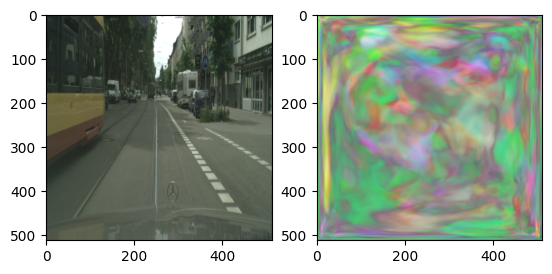

In [7]:

x= next(iter(train_dataloader))
# x = augmentations(x)
x= x.to(device)
rec = model(x)

show =0
fig,ax = plt.subplots(1,2)
ax[0].imshow(x.detach().cpu()[show].permute(1,2,0))
ax[1].imshow(rec.detach().cpu()[show].permute(1,2,0))


In [8]:
epochs = 1

for epoch in range(epochs):
    loop = tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs}')
    # loop = tqdm(range(len(train_dataloader)))
    for batch in loop:
        optimizer.zero_grad()
        batch = batch.to(device)
        # batch=  augmentations(batch)
        rec = model(batch)
       
        loss = reconstruction_loss_fn(rec, batch)

        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())
        losses_list.append(loss.item())
                                                                            
    torch.save(model.state_dict(), config['learning']['model_path'])

Epoch 1/1:  15%|█▍        | 366/2500 [00:51<04:58,  7.15it/s, loss=0.0868]


KeyboardInterrupt: 

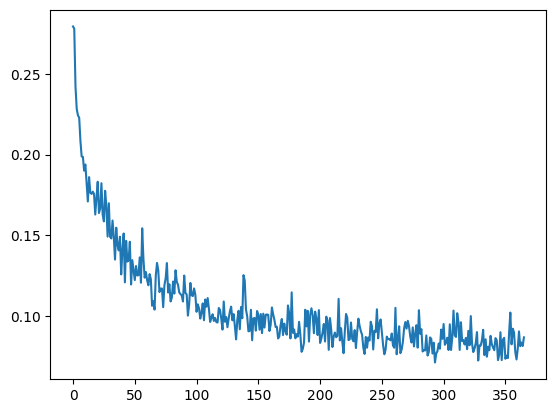

In [9]:
plt.plot(losses_list)

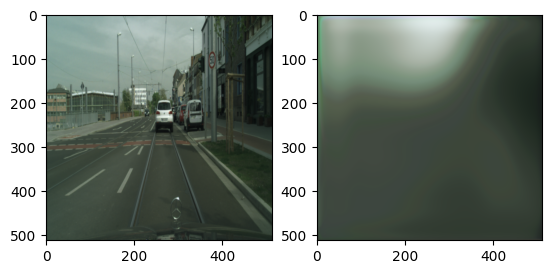

In [11]:

x= next(iter(train_dataloader))
# x = augmentations(x)
x= x.to(device)
rec = model(x)

show =5
fig,ax = plt.subplots(1,2)
ax[0].imshow(x.detach().cpu()[show].permute(1,2,0))
ax[1].imshow(rec.detach().cpu()[show].permute(1,2,0))
